# ex-8 — two-factor model: the complete $(b_1, b_2)$ disk

The ex-6 pipeline with only the **top two factors** (vols 16% / 8%, the market-like factor
and the strongest style). The point of $k = 2$: the $(b_1, b_2)$ projection disk becomes a
**complete** picture of each estimate —

* a dot's **radius** is exactly $\lVert\Pi h_j\rVert = \sqrt{1 - \lVert\Pi^\perp
  h_j\rVert^2}$: the radial deficit *is* the out-of-subspace floor, nothing else;
* a dot's **angle** is the entire in-subspace story: any tilt off its own axis is 1↔2
  leakage — there is no third axis for mass to hide in.

The setup cell computes the **true limiting Gram** from the sampler moments
($\mathbb{E}[\beta_i\beta_j] = \mathrm{loc}_i\mathrm{loc}_j + \delta_{ij}\mathrm{scale}_i^2$)
and takes the population spikes as eigenvalues of $\mathrm{diag}(\sigma)\,G\,
\mathrm{diag}(\sigma)$ — so nonzero means on several factors (which correlate the loading
rows and rotate the eigenbasis away from the drawn directions) are handled correctly, not
assumed away. The spike gap is comfortable (ratio ≈ 5), so this remains the
clean-identification benchmark: what the disks look like when nothing is degenerate. All
figures are measured in the $b$ (eigenbasis) frame, whose statistics depend only on this
spectrum. Same seeds/designs as ex-6; sweeps cached to `ex8_df_{p,n}.parquet`.

In [ ]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import grid, Row, BoxDist, RefOverlay, DiskDensity, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = DATA_DIR / "ex-8_two_factor"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_FORMATS = ("png", "pdf")   # the disk (radial) figures save in each format


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


K = 2
model = ModelSpec(
    k_factors=K,
    factor_vols=[0.16, 0.08],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"

# True limiting Gram from the sampler moments: E[β_i β_j] = loc_i·loc_j + δ_ij·scale_i²
# (independence only kills the noise cross-terms; nonzero locs correlate the rows).
_locs = np.array([s.get("loc", 0.0) for s in model.beta_samplers])
_scales = np.array([s.get("scale", 1.0) for s in model.beta_samplers])
G_limit = np.outer(_locs, _locs) + np.diag(_scales ** 2)
K_limit = np.diag(model.factor_vols) @ G_limit @ np.diag(model.factor_vols)
spikes = np.sort(np.linalg.eigvalsh(K_limit))[::-1]     # true population spikes
print("limiting Gram G:\n", np.round(G_limit, 4))
print("true spikes (eigs of diag(σ)·G·diag(σ)):", np.round(spikes, 5),
      " ratio:", round(spikes[0] / spikes[1], 2))
print("predicted floors at n=63:", np.round(0.16 / (63 * spikes + 0.16), 4))

limiting Gram G:
 [[1.25 0.  ]
 [0.   1.  ]]
true spikes (eigs of diag(σ)·G·diag(σ)): [0.01012 0.0064 ]  ratio: 1.58
predicted floors at n=63: [0.2005 0.2841]


## Steps 1–2 — record + sweeps

Classes carried verbatim from ex-7 (already $k$-generic): per replicate and factor,
`hb1..hb2` $= \langle b_i, h_j\rangle$ and `nu1..nu2` = components of $\hat\nu_j$. Two
sweeps at $R = 1000$, same seed as ex-6: growing $p$ at $n{=}63$, growing $n$ at
$p{=}3000$.

In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k×k realized Gram."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k, n = context.k, context.T
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / n)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        result["nu_coords"] = vecs[:, np.argsort(vals)[::-1]]
        return result


class ProjectedSpectrumAnalysis:
    """Dual-Gram PCA with the finite-p split AND the raw projection coordinates."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        sin2_angle, _ = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)
        coeffs = self.population_loading_directions_b_pop @ H
        in_subspace = (coeffs ** 2).sum(axis=0)
        return {"sin2_j": sin2_angle,
                "measured_out_of_subspace": 1.0 - in_subspace,
                "h_coords": coeffs}


class InSubRotationExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ProjectedSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        C, W = merged["h_coords"], merged["nu_coords"]
        return [{
            "n": n, "p": p, "j": j + 1,
            "sin2_j": float(merged["sin2_j"][j]),
            "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
            "rotation": float(merged["rotation"][j]),
            "measured_out_of_subspace": float(merged["measured_out_of_subspace"][j]),
            **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
            **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
        } for j in range(k)]


design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 63, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)

_REQ = {f"hb{i}" for i in range(1, K + 1)} | {f"nu{i}" for i in range(1, K + 1)}
import json as _json


def _spec_fingerprint(design):
    # Everything that determines the sweep's numbers — model AND design. A cached
    # parquet is valid only if its sidecar fingerprint matches exactly, so editing
    # vols/locs/reps can never silently serve stale data again.
    return _json.dumps({
        "k": model.k_factors, "vols": list(model.factor_vols),
        "betas": model.beta_samplers, "idio": model.idio_vol_sampler,
        "n": list(design.n_values), "p": list(design.p_values),
        "reps": design.n_reps, "seed": design.random_seed,
        "tails": HEAVY_TAIL}, sort_keys=True)


def load_or_run(path, design, label):
    spec = _spec_fingerprint(design)
    sidecar = path.with_suffix(".spec.json")
    if path.exists() and sidecar.exists() and sidecar.read_text() == spec:
        d = pd.read_parquet(path)
        if _REQ <= set(d.columns):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
    if path.exists():
        print(f"{label}: cache stale (spec changed) — re-running")
    d = run_experiment(model, design, InSubRotationExperiment(), progress=True)
    d.to_parquet(path)
    sidecar.write_text(spec)
    print(f"{label}: ran sweep ({len(d):,} rows) → {path.name}")
    return d


df_p = load_or_run(DATA_DIR / "ex8_df_p.parquet", design_p, "growing-p")
df_n = load_or_run(DATA_DIR / "ex8_df_n.parquet", design_n, "growing-n")


replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]


replicate:   0%|          | 1/1000 [00:00<01:59,  8.39rep/s]


replicate:   0%|          | 2/1000 [00:00<03:06,  5.34rep/s]


replicate:   0%|          | 3/1000 [00:00<02:59,  5.56rep/s]


replicate:   0%|          | 4/1000 [00:00<02:54,  5.70rep/s]

...


replicate:  99%|█████████▊| 986/1000 [00:14<00:00, 66.73rep/s]


replicate:  99%|█████████▉| 993/1000 [00:15<00:00, 66.72rep/s]


replicate: 100%|██████████| 1000/1000 [00:15<00:00, 66.80rep/s]


replicate: 100%|██████████| 1000/1000 [00:15<00:00, 66.02rep/s]

growing-n: ran sweep (6,000 rows) → ex8_df_n.parquet


## Step 3 — derive + verify

With $k = 2$ the completeness of the disk is itself a checkable identity: per replicate,
$\mathrm{hb}_1^2 + \mathrm{hb}_2^2 = 1 - \lVert\Pi^\perp h_j\rVert^2$ **exactly** — every
dot's radius is determined by its floor mass and nothing else.

In [3]:
HB = [f"hb{i}" for i in range(1, K + 1)]
NU = [f"nu{i}" for i in range(1, K + 1)]


def derive(df):
    C, W = df[HB].to_numpy(), df[NU].to_numpy()
    norm2 = (C ** 2).sum(axis=1)
    cjj = np.take_along_axis(C, (df["j"].to_numpy() - 1)[:, None], axis=1)[:, 0]
    sgn_h = np.sign(np.take_along_axis(C, np.abs(C).argmax(axis=1)[:, None], axis=1))[:, 0]
    sgn_nu = np.sign(np.take_along_axis(W, np.abs(W).argmax(axis=1)[:, None], axis=1))[:, 0]
    out = df.assign(sin2_in=1.0 - cjj ** 2 / norm2)
    out = out.assign(diff_in_rot=out["sin2_in"] - df["rotation"])
    for i in range(K):
        out[f"hf{i + 1}"] = sgn_h * C[:, i]          # plain projection (folded)
        out[f"nud{i + 1}"] = sgn_nu * W[:, i]        # ν̂ components (folded)
    return out


df_p, df_n = derive(df_p), derive(df_n)

for nm, d in (("growing-p", df_p), ("growing-n", df_n)):
    ident = (d["sin2_j"] - d["measured_out_of_subspace"]) / (1 - d["measured_out_of_subspace"])
    print(f"{nm}: |sin2_in(coords) − sin2_in(identity)| max = "
          f"{(d['sin2_in'] - ident).abs().max():.2e};  "
          f"|radius² − (1−oos)| max = "
          f"{((d[HB] ** 2).sum(axis=1) - (1 - d['measured_out_of_subspace'])).abs().max():.2e}")

growing-p: |sin2_in(coords) − sin2_in(identity)| max = 4.01e-14;  |radius² − (1−oos)| max = 5.55e-17
growing-n: |sin2_in(coords) − sin2_in(identity)| max = 3.89e-14;  |radius² − (1−oos)| max = 5.55e-17


## Step 4 — the complete disk: every replicate as a dot

The centerpiece: all replicates of both factors projected into $(b_1, b_2)$, with mean
arrows. Radius = $\sqrt{1 - \text{floor mass}}$; tilt off own axis = 1↔2 leakage. The
growing-p strip ends in the $\hat\nu$ limit panel (same replicates' realized $F$); the
growing-n strip shows both the floor shrinking (dots moving outward) *and* the angular
spread tightening at once.

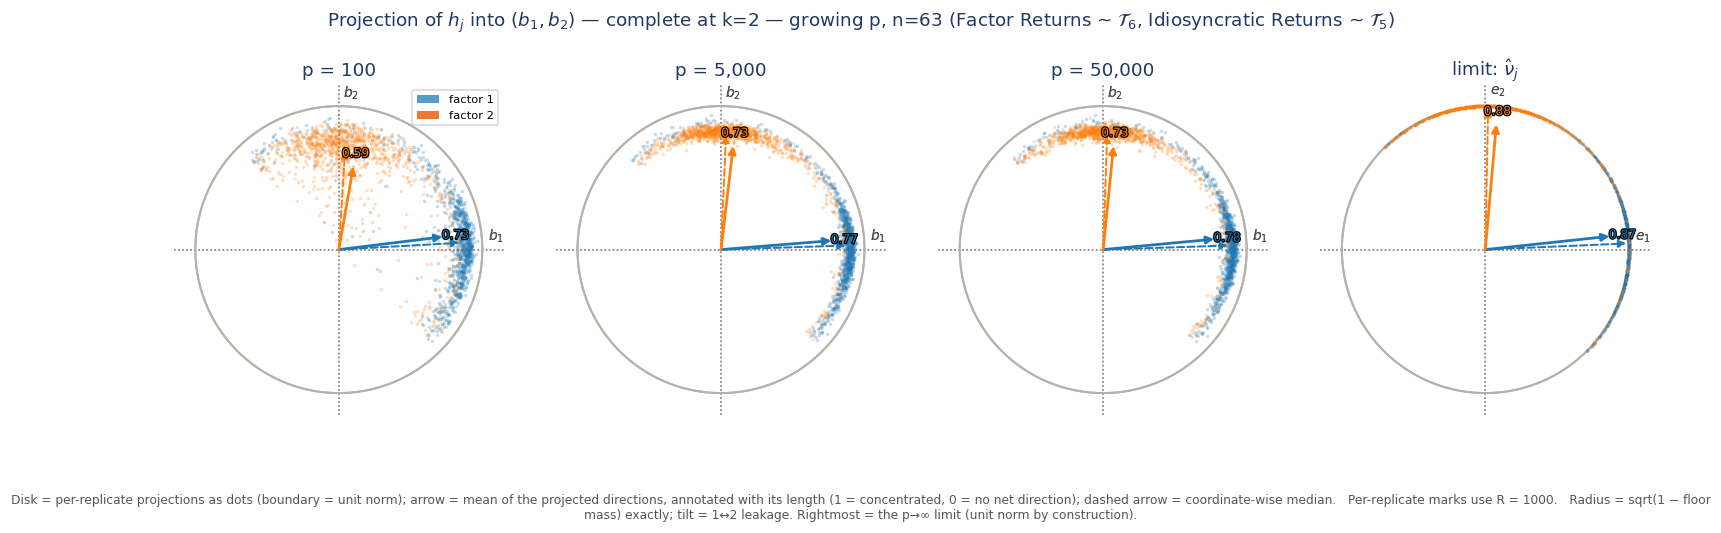

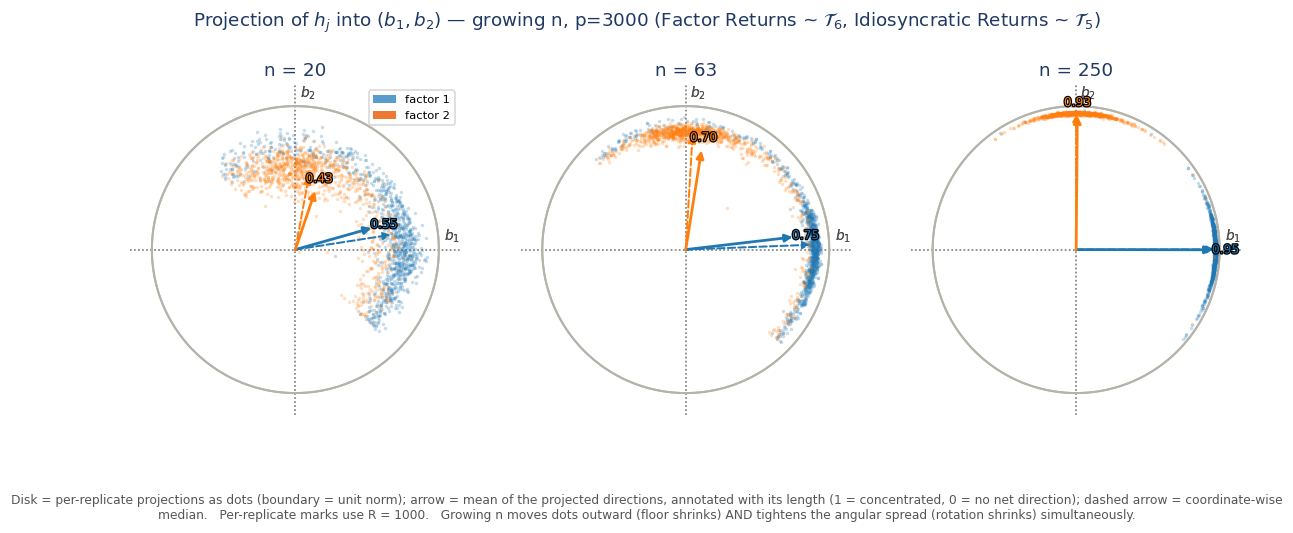

In [4]:
def proj_disk(at, coords="hf", prefix="b"):
    """Both factors' replicates as dots + mean arrows, plain projection."""
    return [DiskDensity(f"{coords}1", f"{coords}2", factor=f, at=at, mean_arrow=True,
                        median_arrow=True,
                        kde=False, scatter=10**6, label=f"factor {f}",
                        labels=(rf"${prefix}_1$", rf"${prefix}_2$"))
            for f in (1, 2)]


_P_STEPS = [100, 5000, 50000]
fig, _ = grid(
    df_p, "p", factors=[1] * (len(_P_STEPS) + 1),
    col_titles=[f"p = {v:,}" for v in _P_STEPS] + [r"limit: $\hat\nu_j$"],
    rows=[Row(cells=[proj_disk({"p": v}) for v in _P_STEPS]
                    + [proj_disk({"p": 50000}, coords="nud", prefix="e")],
              height=1.0)],
    sharey=False, figsize=(15.5, 4.9), formats=FIG_FORMATS,
    suptitle=rf"Projection of $h_j$ into $(b_1, b_2)$ — complete at k=2 — "
             rf"growing p, n=63 {_TAILS}",
    caption_extra="Radius = sqrt(1 − floor mass) exactly; tilt = 1↔2 leakage. "
                  "Rightmost = the p→∞ limit (unit norm by construction).",
    out_path=OUT_DIR / "ex8_proj_growing_p")
show(fig)

fig, _ = grid(
    df_n, "n", factors=[1, 2, 3],
    col_titles=[f"n = {v}" for v in (20, 63, 250)],
    rows=[Row(cells=[proj_disk({"n": v}) for v in (20, 63, 250)], height=1.0)],
    sharey=False, figsize=(11.8, 4.9), formats=FIG_FORMATS,
    suptitle=rf"Projection of $h_j$ into $(b_1, b_2)$ — growing n, p=3000 {_TAILS}",
    caption_extra="Growing n moves dots outward (floor shrinks) AND tightens the angular "
                  "spread (rotation shrinks) simultaneously.",
    out_path=OUT_DIR / "ex8_proj_growing_n")
show(fig)

## Step 5 — scalar view + numbers

The in-subspace rotation distribution with its $k\times k$ limit overlaid, per sweep, and
the 2×2 share matrices. With the near-degenerate pair removed, both factors should
identify cleanly at $n \geq 63$ — this is the benchmark the 3- and 6-factor notebooks
degrade from.

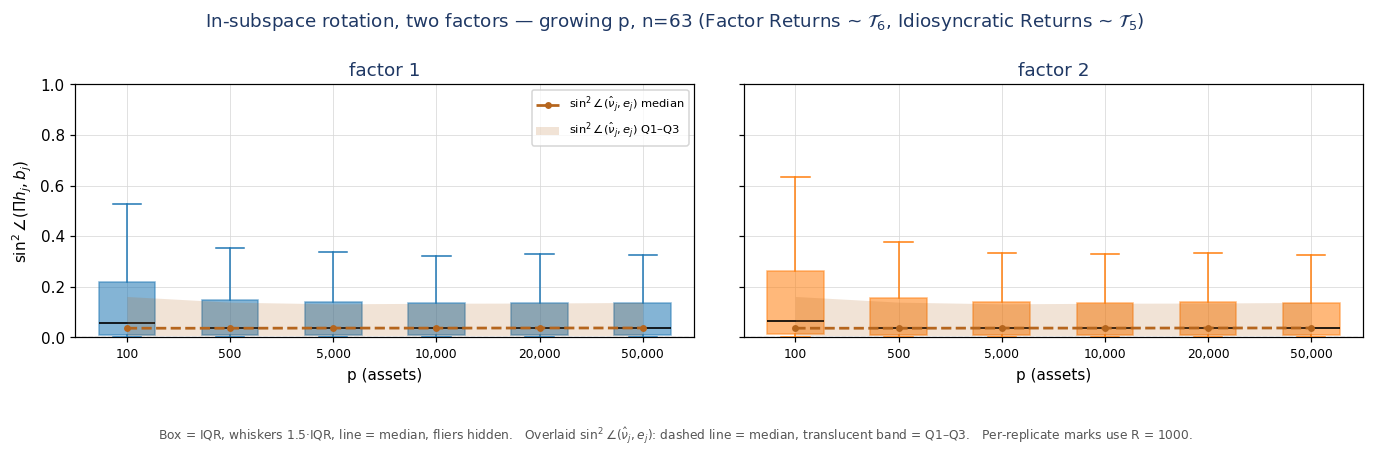

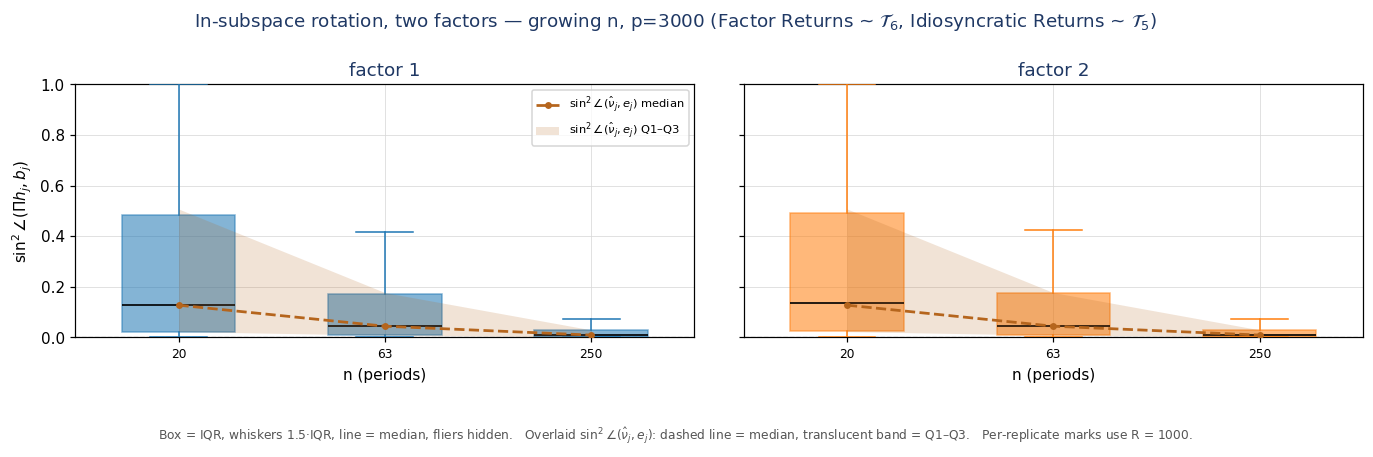

mean in-subspace mass share (%), n=20:


,h1,h2
b1,71.2,29.1
b2,28.8,70.9


mean in-subspace mass share (%), n=63:


,h1,h2
b1,83.2,16.9
b2,16.8,83.1


mean in-subspace mass share (%), n=250:


,h1,h2
b1,96.9,3.1
b2,3.1,96.9


∠(b_j, h_j) in degrees (median / p95), growing p at n=63:


median   p95
p     j              
100   1    33.0  73.8
      2    46.5  80.0
500   1    30.1  68.5
      2    38.5  69.8
5000  1    29.8  67.3
      2    36.9  68.8
10000 1    29.9  68.6
      2    36.9  69.1
20000 1    29.8  67.4
      2    36.8  68.2
50000 1    29.8  66.5
      2    36.8  67.5

In [5]:
for df, key, lab, stem in ((df_p, "p", "growing p, n=63", "ex8_insub_dist_p"),
                           (df_n, "n", "growing n, p=3000", "ex8_insub_dist_n")):
    fig, _ = grid(df, key,
                  rows=[Row([BoxDist("sin2_in"),
                             RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                            ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
                  sharey=True,
                  suptitle=f"In-subspace rotation, two factors — {lab} {_TAILS}",
                  out_path=OUT_DIR / stem)
    show(fig)


def share_matrix(df, at):
    s = df
    for c, v in at.items():
        s = s[s[c] == v]
    C2 = s[HB].to_numpy() ** 2
    C2 = C2 / C2.sum(axis=1, keepdims=True)
    return pd.DataFrame({f"h{j}": 100 * C2[s["j"].to_numpy() == j].mean(axis=0)
                         for j in range(1, K + 1)},
                        index=[f"b{i}" for i in range(1, K + 1)]).round(1)


for v in (20, 63, 250):
    print(f"mean in-subspace mass share (%), n={v}:")
    display(share_matrix(df_n, {"n": v}))

print("∠(b_j, h_j) in degrees (median / p95), growing p at n=63:")
_a = df_p.assign(ang=np.degrees(np.arccos(
    np.abs(df_p[HB].to_numpy()[np.arange(len(df_p)), df_p["j"].to_numpy() - 1]))))
display(_a.groupby(["p", "j"])["ang"]
          .agg(median="median", p95=lambda s: s.quantile(0.95)).round(1))

## Step 6 — coordinate marginals: one boxplot per inner product

Each panel is one inner product $\langle h_i, b_j\rangle$ — the cosine of the angle
between that estimated factor and that population direction — as a per-replicate
distribution across the sweep. Pairs are sign-folded (each replicate's pair flipped
together so the own-axis coordinate is positive); the dashed zero line is the reference
for the cross terms.

**What to look for:** the **diagonal** panels ($\langle h_1, b_1\rangle$,
$\langle h_2, b_2\rangle$) sit *below 1* — the attenuation $\cos\angle \approx$ 0.96 /
0.84, i.e. the persistent per-replicate angles (~17° / ~33°) that fixed $n$ cannot
remove. The **off-diagonal** panels are centered on 0 with shrinking spread — the errors
distribute evenly around the truth, which is why the mean arrows in Step 4 are parallel
to the axes.

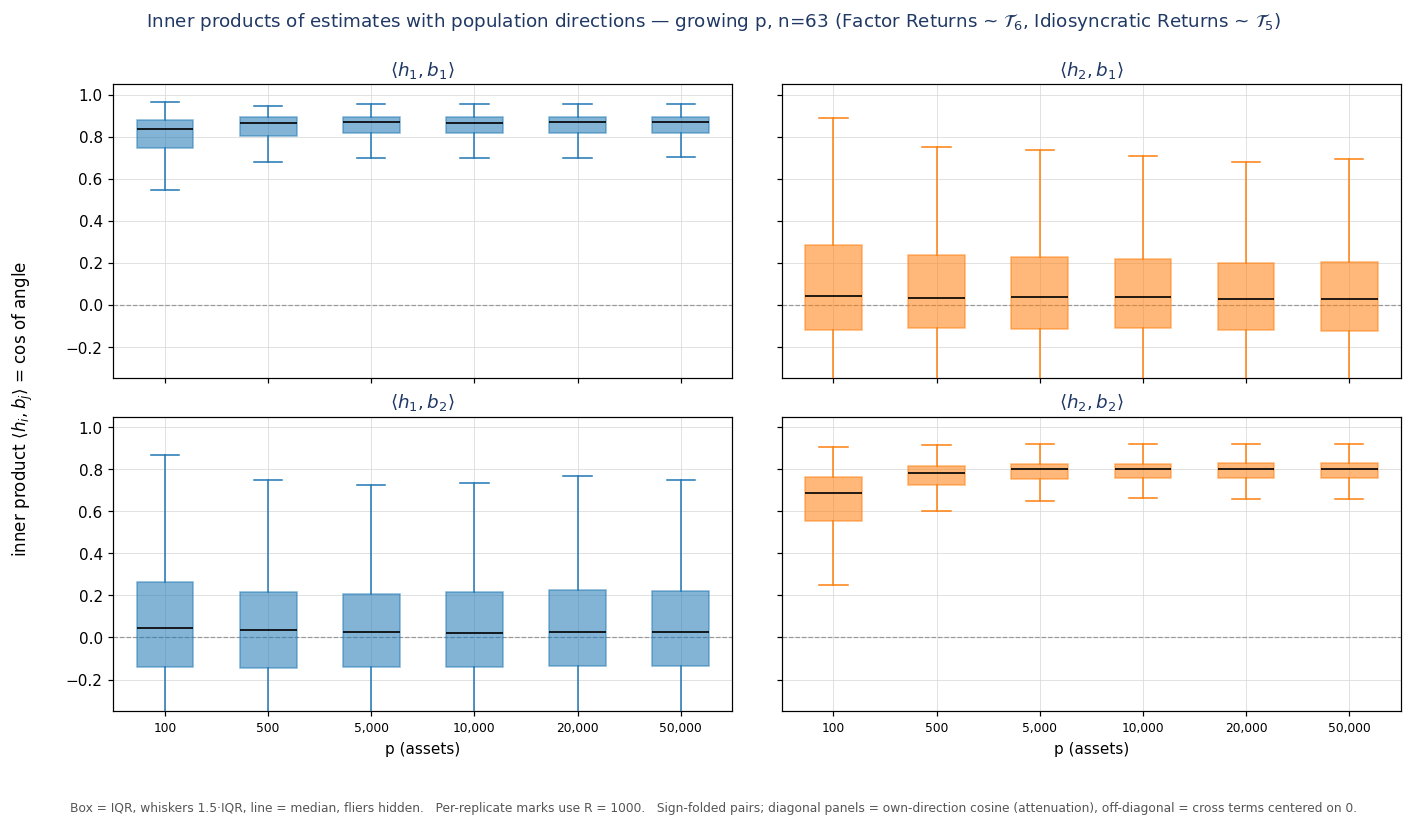

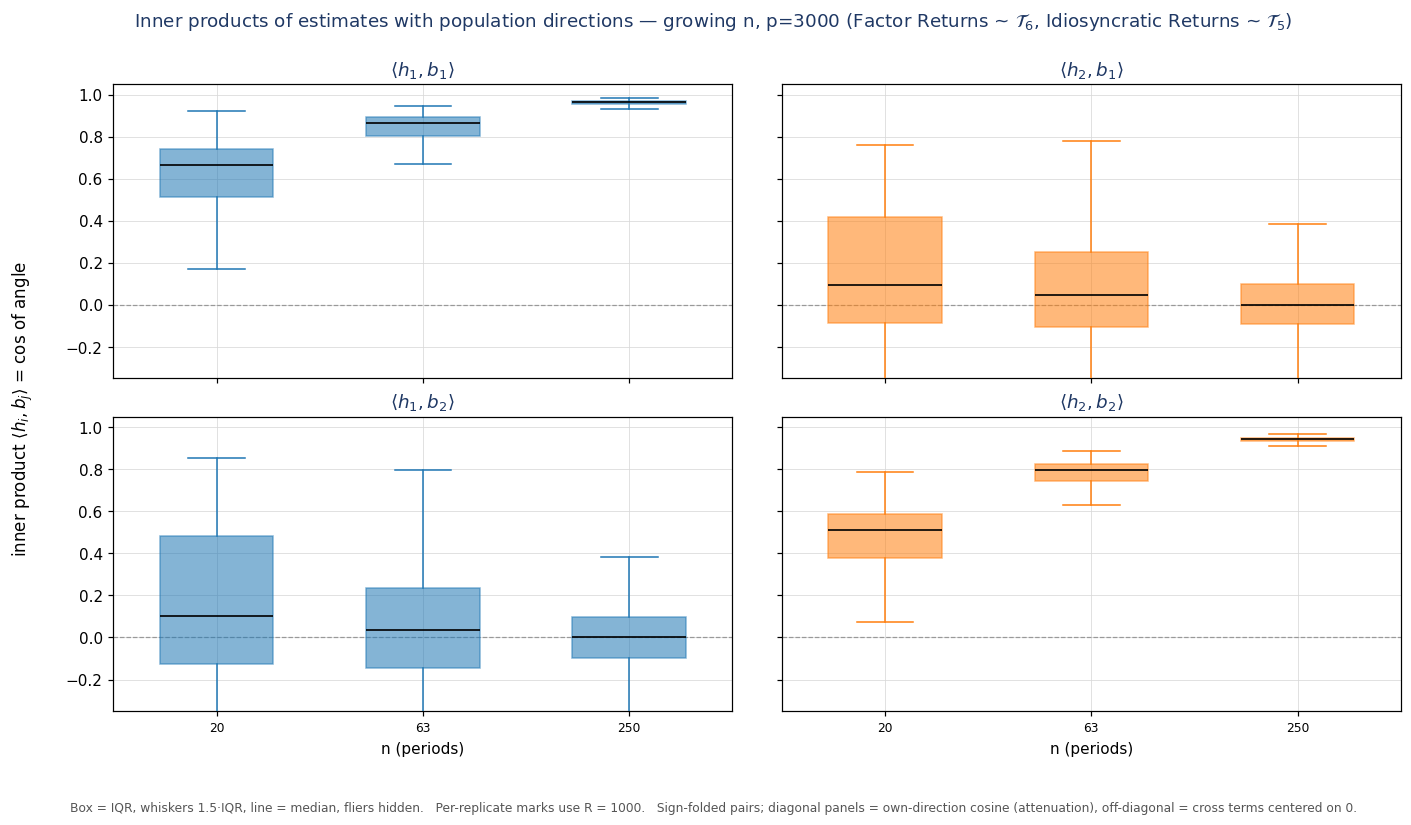

In [6]:
from fl_plot import save as fl_save

for df, key, lab, stem in ((df_p, "p", "growing p, n=63", "ex8_coord_box_p"),
                           (df_n, "n", "growing n, p=3000", "ex8_coord_box_n")):
    fig, axes = grid(df, key,
                     rows=[Row(BoxDist("hf1"), ylabel="", ylim=(-0.35, 1.05), height=1.0),
                           Row(BoxDist("hf2"), ylabel="", ylim=(-0.35, 1.05), height=1.0)],
                     sharey=True,
                     suptitle=f"Inner products of estimates with population directions — {lab} {_TAILS}",
                     caption_extra="Sign-folded pairs; diagonal panels = own-direction "
                                   "cosine (attenuation), off-diagonal = cross terms "
                                   "centered on 0.")
    # per-panel labels: rows are b_1, b_2; columns are h_1, h_2
    for ri, bi in enumerate((1, 2)):
        for ci, hi in enumerate((1, 2)):
            axes[ri, ci].set_title(rf"$\langle h_{hi}, b_{bi}\rangle$",
                                   color=THEME.navy, fontsize=12)
    fig.supylabel(r"inner product $\langle h_i, b_j\rangle$ = cos of angle", fontsize=11)
    fl_save(fig, OUT_DIR / stem)
    show(fig)

---
## Change log

- **2026-08-05**: new notebook — the ex-6 pipeline with only the top two factors
  (vols 16%/8%, spike ratio 5.0). At k=2 the $(b_1, b_2)$ projection disk is complete
  (radius² = 1 − floor mass exactly, verified per replicate; tilt = the entire in-subspace
  leakage), making it the clean-identification benchmark for the 3- and 6-factor
  notebooks. Dots + mean arrows throughout (`DiskDensity(kde=False)`); sweeps cached to
  `ex8_df_{p,n}.parquet`; figures → `nb_outputs/ex-8_two_factor/`.
- **2026-08-05**: Step 6 — coordinate-marginal boxplots of the folded $\langle b_i, h_j\rangle$ per factor and sweep (own coordinate = attenuation, transverse centered on 0).
